Loan data Outliers

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler  
import numpy as np

In [14]:
df= pd.read_csv("../data/loan_nomissing.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


<Axes: >

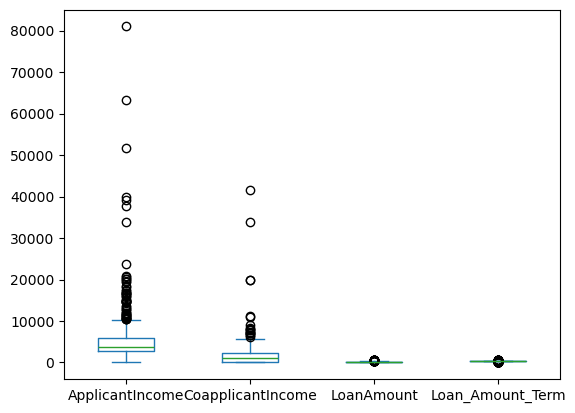

In [15]:
columns_with_outliers = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]
df[columns_with_outliers].plot.box()

In [16]:
df.shape

(614, 13)

In [17]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.752443,342.410423,0.855049
std,6109.041673,2926.248369,84.107233,64.428629,0.352339
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000
50%,3812.500000,1188.500000,128.000000,360.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


Removing Outliers

In [18]:
q1= np.quantile(df["ApplicantIncome"], 0.25)
q3= np.quantile(df["ApplicantIncome"], 0.75)
iqr = q3 - q1
lower_bound = q1 - 8 * iqr
upper_bound = q3 + 8 * iqr
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

Lower bound: -20462.5, Upper bound: 29135.0


In [19]:
df = df[(df["ApplicantIncome"] >= lower_bound) & (df["ApplicantIncome"] <= upper_bound)]
df.shape

(607, 13)

In [20]:
q1= np.quantile(df["CoapplicantIncome"], 0.25)
q3= np.quantile(df["CoapplicantIncome"], 0.75)  
iqr = q3 - q1
lower_bound = q1 - 5 * iqr  
upper_bound = q3 + 5 * iqr
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

Lower bound: -11520.0, Upper bound: 13824.0


In [21]:
df = df[(df["CoapplicantIncome"] >= lower_bound) & (df["CoapplicantIncome"] <= upper_bound)]
df.shape

(603, 13)

In [22]:
df.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

In [23]:
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


Encoding the binary features

In [24]:
df["Property_Area"].unique().tolist()

['Urban', 'Rural', 'Semiurban']

In [25]:
df["Dependents"].unique().tolist()

['0', '1', '2', '3+']

In [27]:
df["Loan_Status"] = np.where(df["Loan_Status"] == "Y", 1, 0)
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,1
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,0
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,1
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,0


In [ ]:
df["Dependents"] = np.where(df["Dependents"] == "3+", 3, df["Dependents"])
df["Dependents"] = df["Dependents"].astype(int)
df["Dependents"].unique().tolist()


[0, 1, 2, 3]

In [30]:
df["Dependents"].dtype

dtype('int64')

In [34]:
df.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents             int64
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status            int64
dtype: object

In [36]:
correlation_matrix = df.corr(method='pearson', numeric_only=True)
correlation_matrix

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
Dependents,1.000000,0.072279,-0.004986,0.111511,-0.088241,-0.036868,0.014376
ApplicantIncome,0.072279,1.000000,-0.148225,0.607536,0.017528,0.058812,-0.007841
CoapplicantIncome,-0.004986,-0.148225,1.000000,0.288495,-0.030331,-0.029286,0.012915
LoanAmount,0.111511,0.607536,0.288495,1.000000,0.102715,0.023816,-0.037269
Loan_Amount_Term,-0.088241,0.017528,-0.030331,0.102715,1.000000,-0.011203,-0.021280
Credit_History,-0.036868,0.058812,-0.029286,0.023816,-0.011203,1.000000,0.551213
Loan_Status,0.014376,-0.007841,0.012915,-0.037269,-0.021280,0.551213,1.000000


In [37]:
df["Education"].unique().tolist()

['Graduate', 'Not Graduate']

In [ ]:
df["Self_Employed"] = np.where(df["Self_Employed"] == "Yes", 1, 0)
df["Married"] = np.where(df["Married"] == "Yes", 1, 0)
df["Gender"] = np.where(df["Gender"] == "Male", 1, 0)
df["Education"] = np.where(df["Education"] == "Graduate", 1, 0)
df.head(10)




,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,Urban,1
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,Urban,1
5,LP001011,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,Urban,1
6,LP001013,1,1,0,0,0,2333,1516.0,95.0,360.0,1.0,Urban,1
7,LP001014,1,1,3,1,0,3036,2504.0,158.0,360.0,0.0,Semiurban,0
8,LP001018,1,1,2,1,0,4006,1526.0,168.0,360.0,1.0,Urban,1
9,LP001020,1,1,1,1,0,12841,10968.0,349.0,360.0,1.0,Semiurban,0


Encoding Categorical feature with Onehot Encoder

In [ ]:
#Load and fit and transform the one-hot encoder
one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
one_hot_encoded = one_hot_encoder.fit_transform(df[["Property_Area"]])
one_hot_encoder

,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [ ]:
#Get the column names of the one-hot encoded features
columns_names = one_hot_encoder.get_feature_names_out(["Property_Area"])
columns_names

array(['Property_Area_Rural', 'Property_Area_Semiurban',
       'Property_Area_Urban'], dtype=object)

In [43]:
#Create a DataFrame from the one-hot encoded features
df_transformed = pd.DataFrame(one_hot_encoded, columns=columns_names)
df_transformed.head()

,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0


In [44]:
#Drop the original "Property_Area" column from the original DataFrame
df = df.drop("Property_Area", axis=1)
#Join the original DataFrame with the one-hot encoded DataFrame
df = df.join(df_transformed)
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,1,0.0,0.0,1.0
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,1.0,0.0,0.0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,0.0,0.0,1.0
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,0.0,0.0,1.0
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,0.0,0.0,1.0


In [45]:
df.to_csv("../data/loan_encoded.csv", index=False)